In [3]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv(r'C:\Users\PC\Desktop\محرومیت\data\labour_force_all_3.csv',low_memory=False)

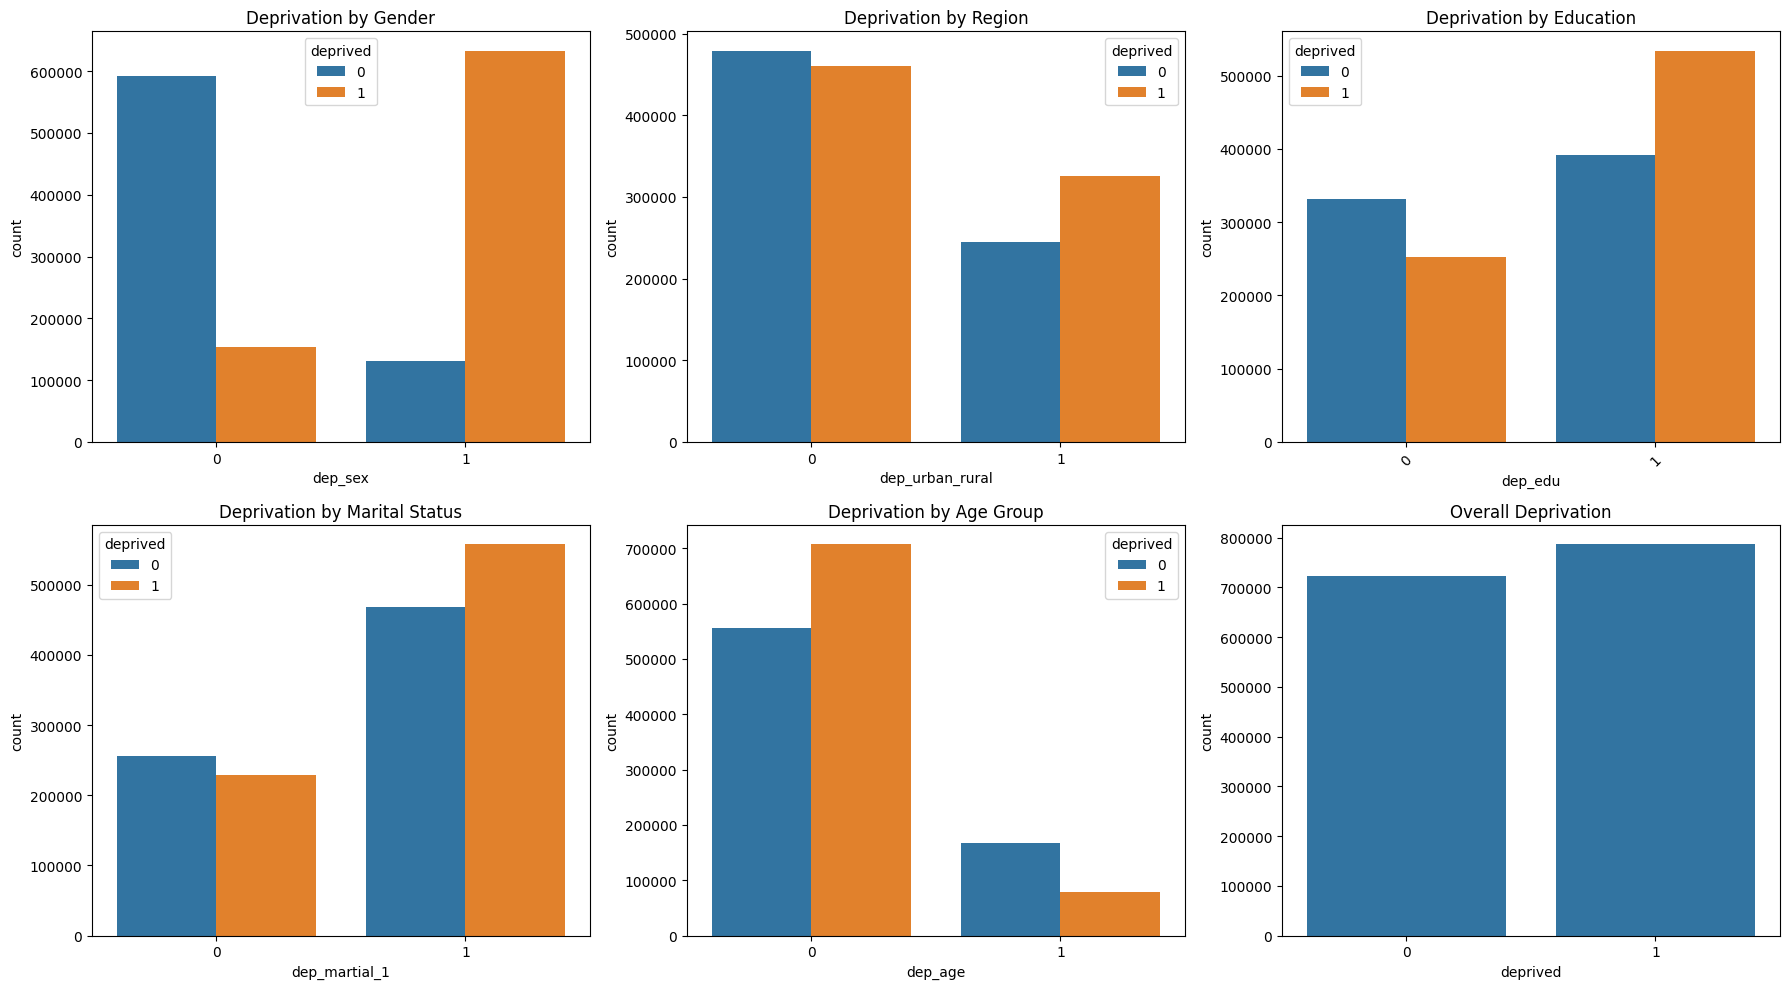

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# نمودار محرومیت بر اساس جنسیت و منطقه
# ============================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. جنسیت
sns.countplot(data=df, x='dep_sex', hue='deprived', ax=axes[0,0])
axes[0,0].set_title('Deprivation by Gender')

# 2. منطقه
sns.countplot(data=df, x='dep_urban_rural', hue='deprived', ax=axes[0,1])
axes[0,1].set_title('Deprivation by Region')

# 3. تحصیلات
sns.countplot(data=df, x='dep_edu', hue='deprived', ax=axes[0,2])
axes[0,2].set_title('Deprivation by Education')
axes[0,2].tick_params(axis='x', rotation=45)

# 4. وضعیت تاهل
sns.countplot(data=df, x='dep_martial_1', hue='deprived', ax=axes[1,0])
axes[1,0].set_title('Deprivation by Marital Status')

# 5. گروه سنی
sns.countplot(data=df, x='dep_age', hue='deprived', ax=axes[1,1])
axes[1,1].set_title('Deprivation by Age Group')

# 6. محرومیت کلی
sns.countplot(data=df, x='deprived', ax=axes[1,2])
axes[1,2].set_title('Overall Deprivation')

plt.tight_layout()
plt.savefig('deprivation_by_variables.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================
# ۲. تابع اصلاح‌شده
# ============================================

def deprivation_percent_plot(df, var, title, deprived_col='deprived'):
    """
    رسم نمودار درصد محرومیت به تفکیک یک متغیر
    """
    # بررسی وجود ستون‌ها
    if var not in df.columns:
        print(f"⚠️ ستون {var} وجود ندارد")
        return
    
    if deprived_col not in df.columns:
        print(f"⚠️ ستون {deprived_col} وجود ندارد")
        return
    
    # ایجاد جدول متقاطع
    grouped = pd.crosstab(df[var], df[deprived_col], normalize='index') * 100
    grouped = grouped.round(1)
    
    # اطمینان از وجود هر دو ستون ۰ و ۱
    if 0 not in grouped.columns:
        grouped[0] = 0
    if 1 not in grouped.columns:
        grouped[1] = 0
    grouped = grouped[[0, 1]]  # مرتب‌سازی: غیرمحروم، محروم
    
    # رسم نمودار
    fig, ax = plt.subplots(figsize=(10, 6))
    grouped.plot(kind='bar', stacked=True, ax=ax, color=['green', 'red'])
    ax.set_title(f'Deprivation by {title}', fontsize=14)
    ax.set_xlabel(title)
    ax.set_ylabel('Percent (%)')
    ax.legend(['Not Deprived', 'Deprived'])
    ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5)
    
    # اضافه کردن درصد روی نمودار (فقط برای ستون محرومیت)
    for i, (idx, row) in enumerate(grouped.iterrows()):
        if row[1] > 0:
            ax.text(i, row[1]/2, f"{row[1]:.1f}%", 
                    ha='center', va='center', color='white', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(f'deprivation_percent_{var}.png', dpi=300)
    plt.show()
    
    return grouped

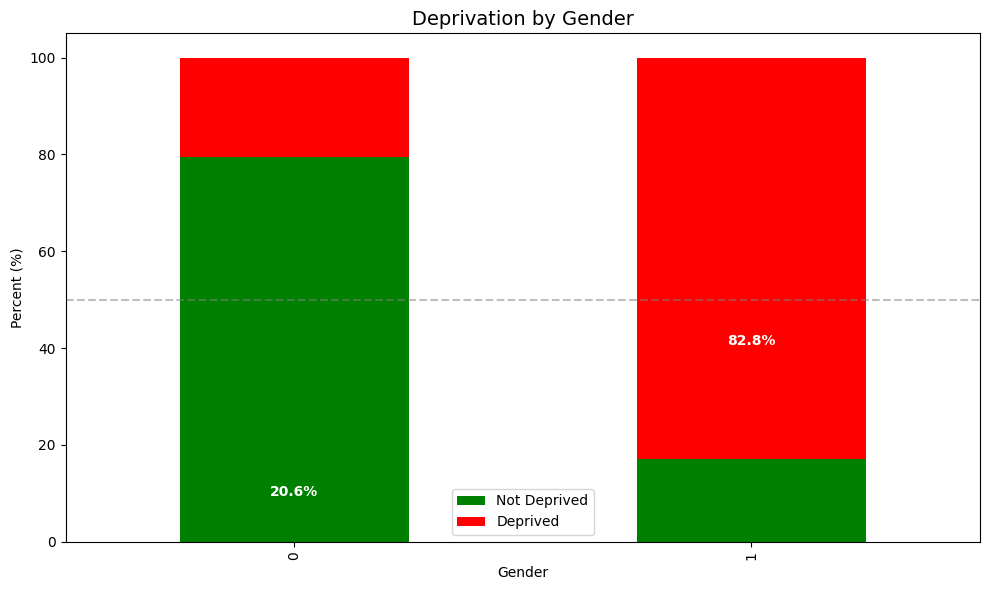

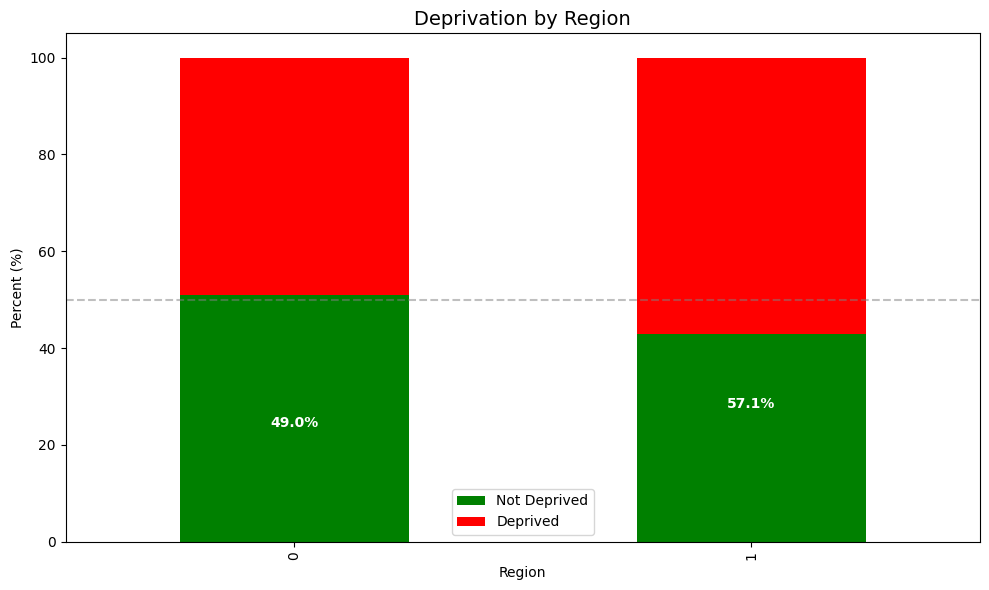

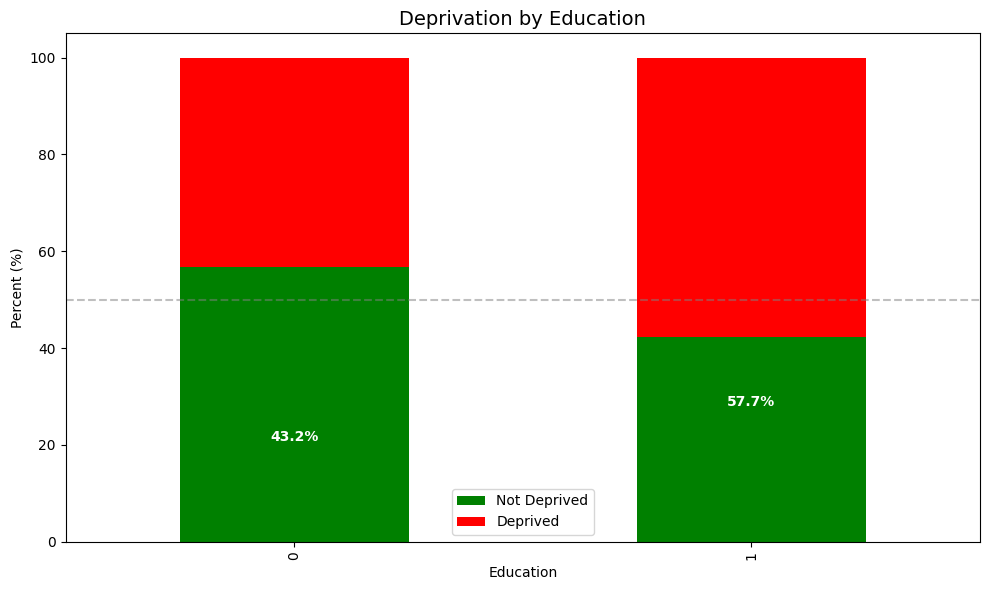

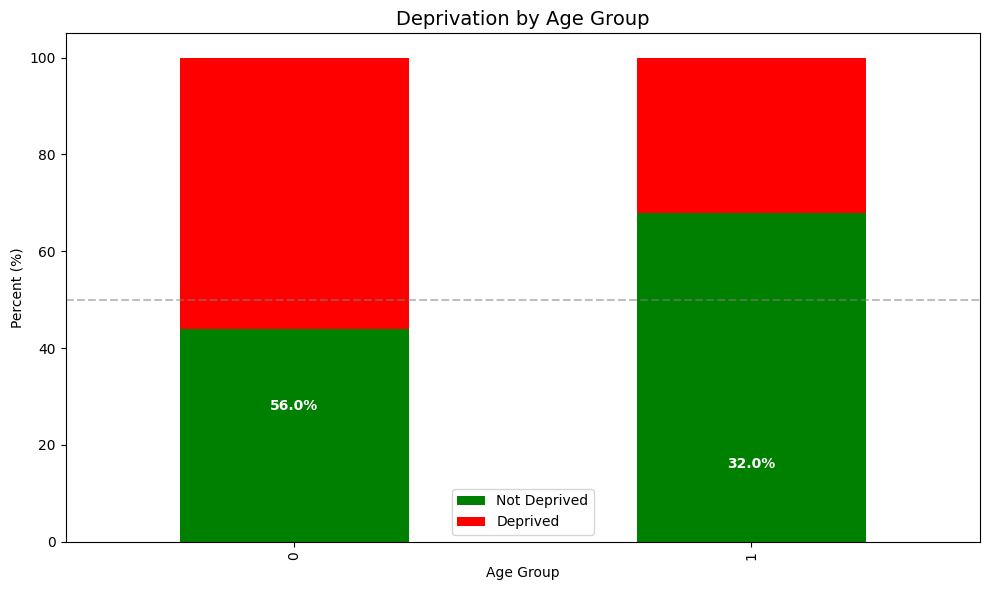

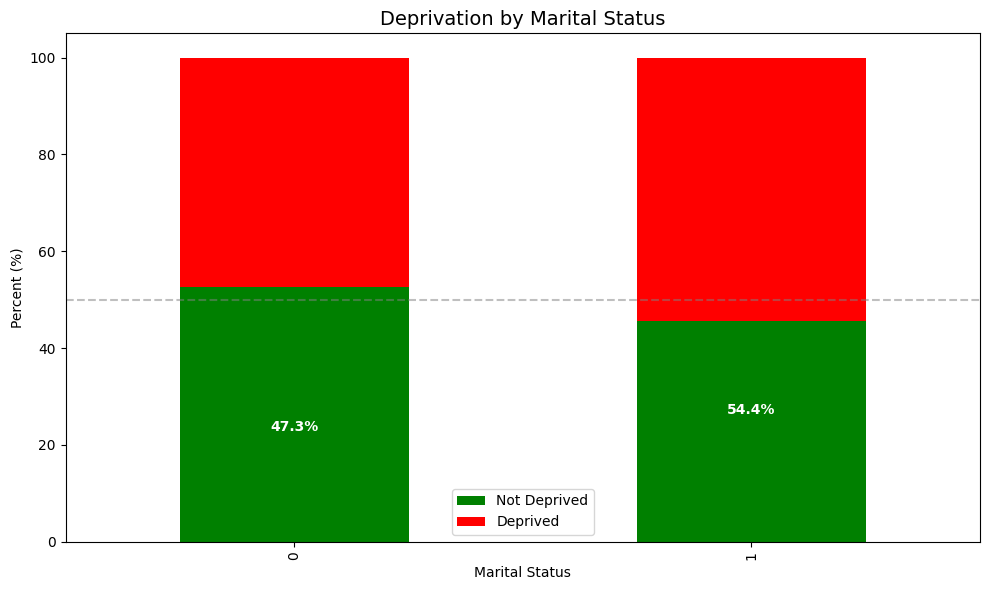

deprived,0,1
dep_martial_1,,
0,52.7,47.3
1,45.6,54.4


In [12]:
# ============================================
# ۳. اجرا با ستون‌های واقعی
# ============================================

# ستون‌های موجود در داده شما
# بر اساس کدهای قبلی که داری:
# - F2_D04 = جنسیت
# - urban_rural = منطقه
# - education_group = گروه تحصیلی
# - Age_Group = گروه سنی
# - marital_Label = وضعیت تاهل
# - deprived = محرومیت

# اجرا برای متغیرهای مختلف
deprivation_percent_plot(df, 'dep_sex', 'Gender')
deprivation_percent_plot(df, 'dep_urban_rural', 'Region')
deprivation_percent_plot(df, 'dep_edu', 'Education')
deprivation_percent_plot(df, 'dep_age', 'Age Group')
deprivation_percent_plot(df, 'dep_martial_1', 'Marital Status')

ستون‌های موجود: ['Unnamed: 0.4', 'Unnamed: 0.3', 'Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0', 'pkey', 'NobatAmargiri', 'F2_D03', 'F2_D04', 'F2_D05', 'F2_D06', 'F2_D07', 'F2_D15', 'F2_D16', 'F2_D17', 'F2_D18', 'F2_D19', 'F3_D01', 'F3_D02', 'F3_D03', 'F3_D04', 'F3_D05', 'F3_D06', 'F3_D09', 'F3_D11', 'F3_D13', 'F3_D24', 'F3_D31', 'F3_D33', 'F3_D47', 'F3_D49', 'IW_Yearly', 'ActivityStatus', 'year', 'household_number', 'cluster_number', 'urban_rural', 'province_code', 'sample_year', 'education_group', 'dep_sex', 'dep_urban_rural', 'dep_edu', 'dep_age_group', 'deprived', 'Province', 'dep_martial_1', 'dep_martial_2', 'dep_martial_3', 'dep_age']


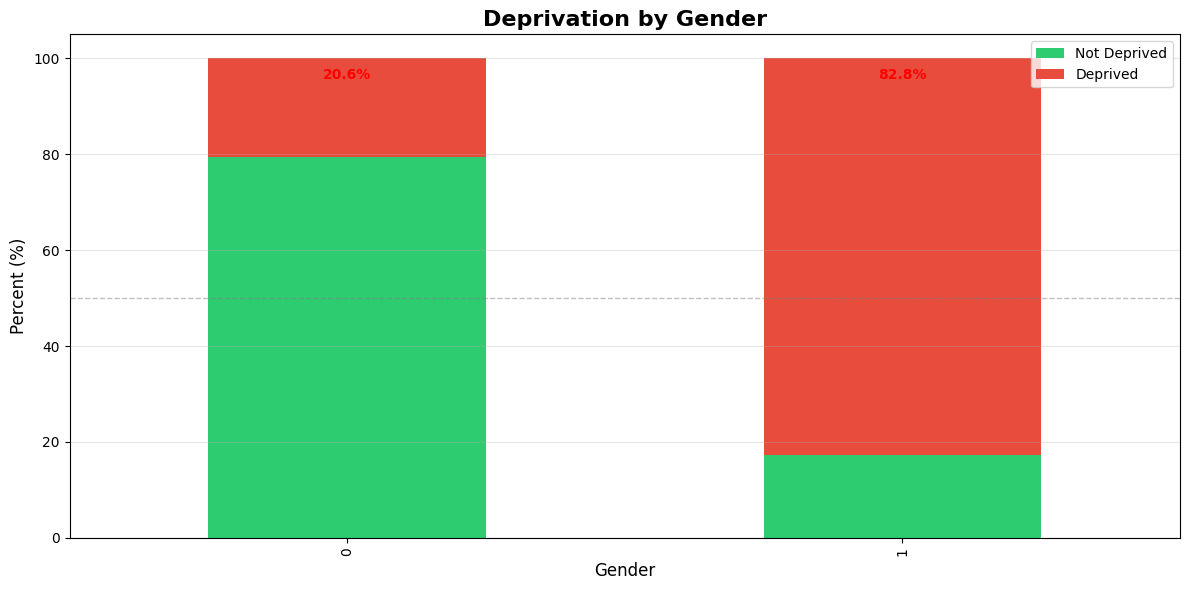

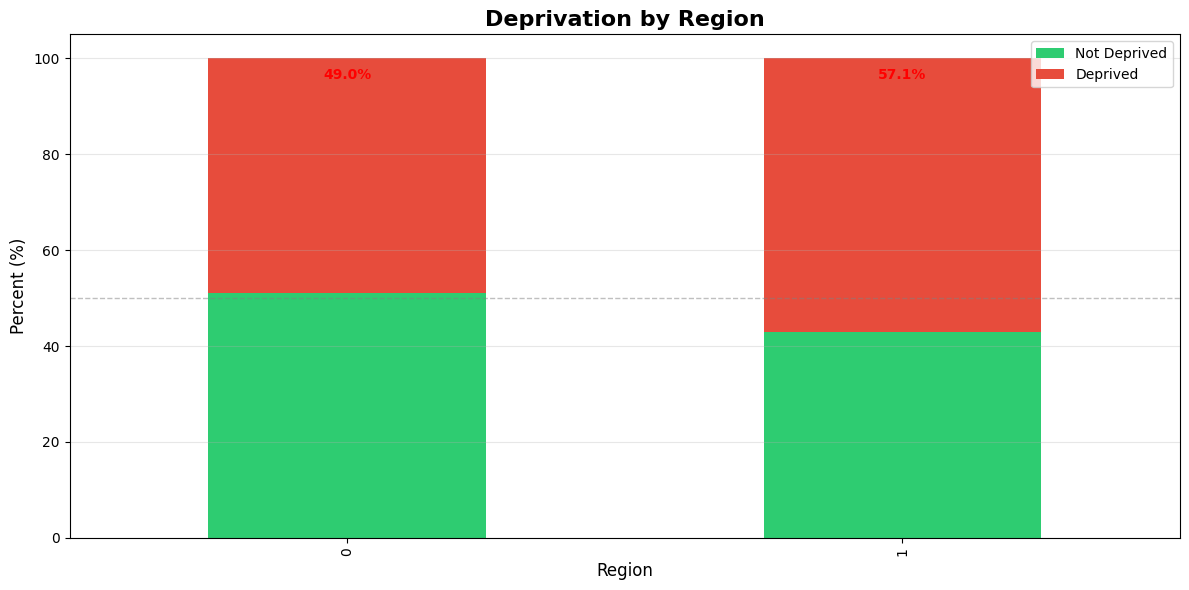

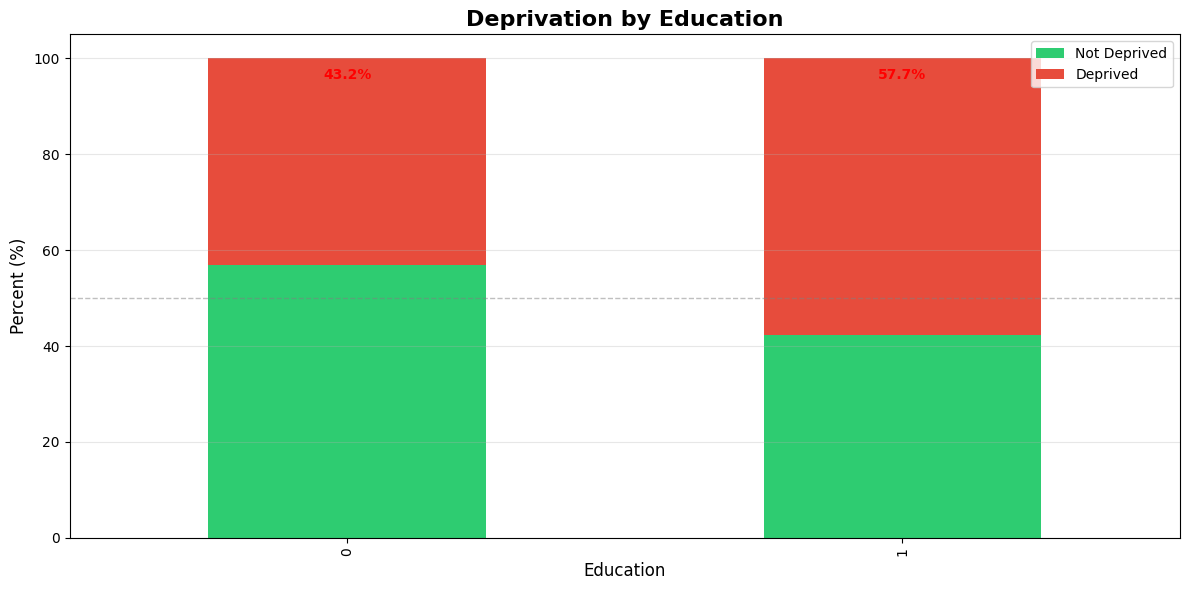

deprived,0,1
dep_edu,,
0,56.8,43.2
1,42.3,57.7


In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================
# تابع رسم نمودار درصد محرومیت
# ============================================

def deprivation_percent_plot(df, var, title):
    """نمودار درصد محرومیت به تفکیک یک متغیر"""
    
    # اطمینان از وجود ستون‌ها
    if var not in df.columns:
        print(f"⚠️ ستون {var} وجود ندارد")
        return
    
    if 'deprived' not in df.columns:
        print("⚠️ ستون 'deprived' وجود ندارد")
        return
    
    # ایجاد جدول توافقی (درصد در هر ردیف)
    grouped = pd.crosstab(df[var], df['deprived'], normalize='index') * 100
    grouped = grouped.round(1)
    
    # اگر ستون‌ها به ترتیب نبودند، مرتب کن
    if 0 in grouped.columns and 1 in grouped.columns:
        grouped = grouped[[0, 1]]  # 0 = Not Deprived, 1 = Deprived
        col_names = ['Not Deprived', 'Deprived']
    else:
        col_names = grouped.columns.tolist()
    
    # رسم نمودار
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # رسم stacked bar
    grouped.plot(kind='bar', stacked=True, ax=ax, color=['#2ecc71', '#e74c3c'])
    
    # تنظیمات
    ax.set_title(f'Deprivation by {title}', fontsize=16, fontweight='bold')
    ax.set_xlabel(title, fontsize=12)
    ax.set_ylabel('Percent (%)', fontsize=12)
    ax.legend(col_names, loc='upper right')
    ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.grid(axis='y', alpha=0.3)
    
    # اضافه کردن درصد روی نمودار
    for i, (idx, row) in enumerate(grouped.iterrows()):
        # درصد محرومیت (ستون 1)
        deprived_pct = row.iloc[1] if len(row) > 1 else 0
        # درصد غیرمحرومیت (ستون 0)
        not_deprived_pct = row.iloc[0] if len(row) > 0 else 0
        
        # نمایش درصد محرومیت در بالای هر ستون
        if deprived_pct > 0:
            ax.text(i, 100 - 2, f"{deprived_pct:.1f}%", 
                    ha='center', va='top', color='red', fontweight='bold', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(f'deprivation_percent_{var}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return grouped

# ============================================
# اجرا برای متغیرهای مختلف
# ============================================

# ابتدا بررسی کنیم ستون‌ها وجود دارند
print("ستون‌های موجود:", df.columns.tolist())

# اجرای نمودارها با نام‌های واقعی ستون‌ها
deprivation_percent_plot(df, 'dep_sex', 'Gender')
deprivation_percent_plot(df, 'dep_urban_rural', 'Region')
deprivation_percent_plot(df, 'dep_edu', 'Education')

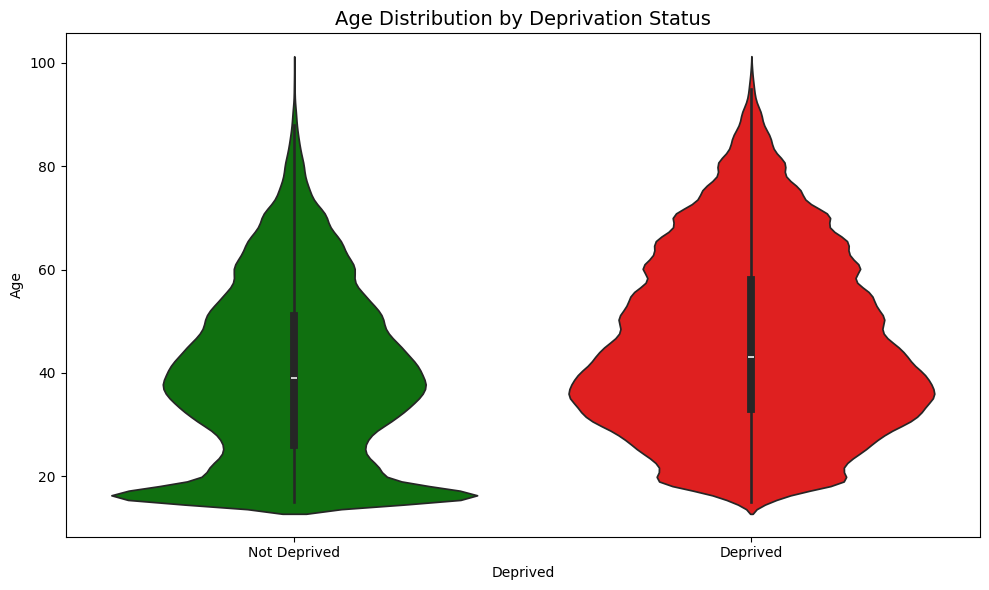

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# Violin Plot: توزیع سن در محرومیت و غیرمحرومیت
# ============================================

fig, ax = plt.subplots(figsize=(10, 6))

# اصلاح ۱: استفاده از hue به جای palette
sns.violinplot(data=df, x='deprived', y='F2_D07', hue='deprived', 
               palette=['green', 'red'], legend=False, ax=ax)

ax.set_title('Age Distribution by Deprivation Status', fontsize=14)
ax.set_xlabel('Deprived')
ax.set_ylabel('Age')

# اصلاح ۲: تنظیم صحیح برچسب‌ها
ax.set_xticks([0, 1])
ax.set_xticklabels(['Not Deprived', 'Deprived'])

plt.tight_layout()
plt.savefig('age_violin.png', dpi=300)
plt.show()

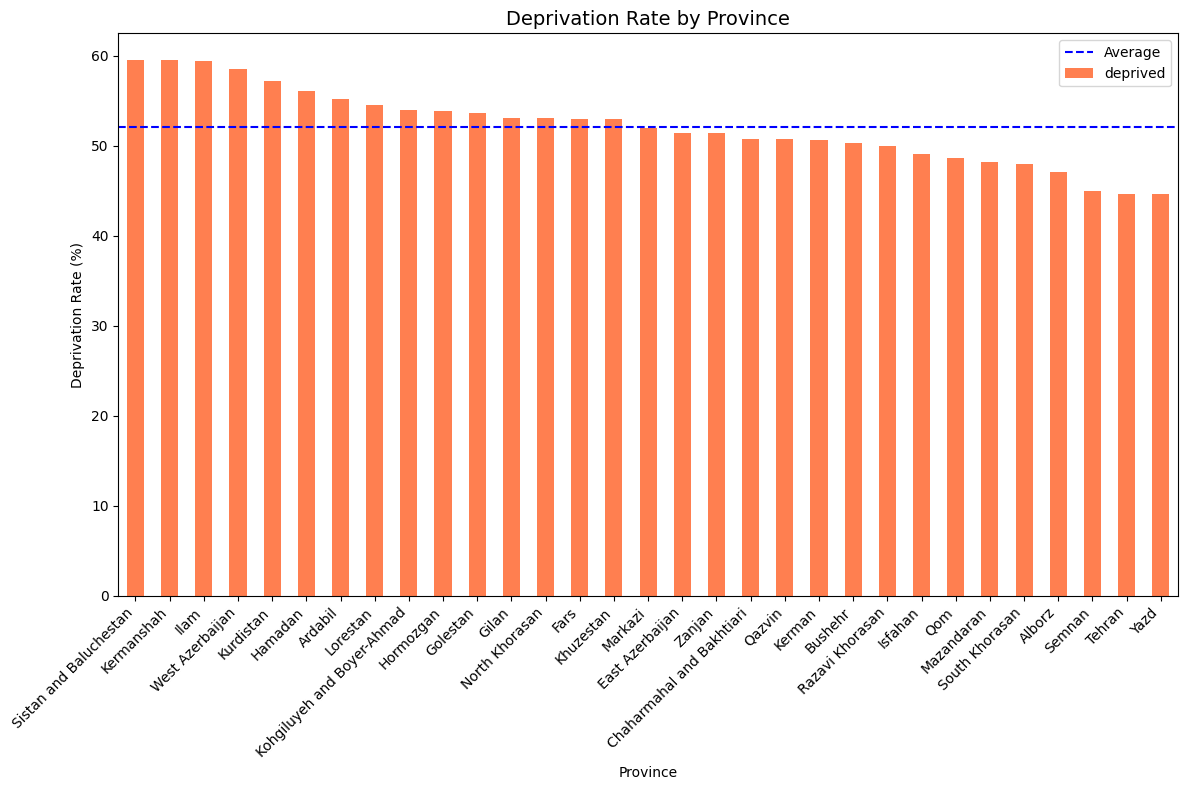

In [16]:
# ============================================
# محرومیت در استان‌های مختلف
# ============================================

# محاسبه درصد محرومیت در هر استان
province_dep = df.groupby('Province')['deprived'].mean() * 100
province_dep = province_dep.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
province_dep.plot(kind='bar', color='coral', ax=ax)
ax.set_title('Deprivation Rate by Province', fontsize=14)
ax.set_xlabel('Province')
ax.set_ylabel('Deprivation Rate (%)')
ax.axhline(y=province_dep.mean(), color='blue', linestyle='--', label='Average')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('deprivation_by_province.png', dpi=300)
plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_18028\3686656314.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='deprived', y='F2_D07', palette=['green', 'red'])
C:\Users\PC\AppData\Local\Temp\ipykernel_18028\3686656314.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Deprived', 'Deprived'])


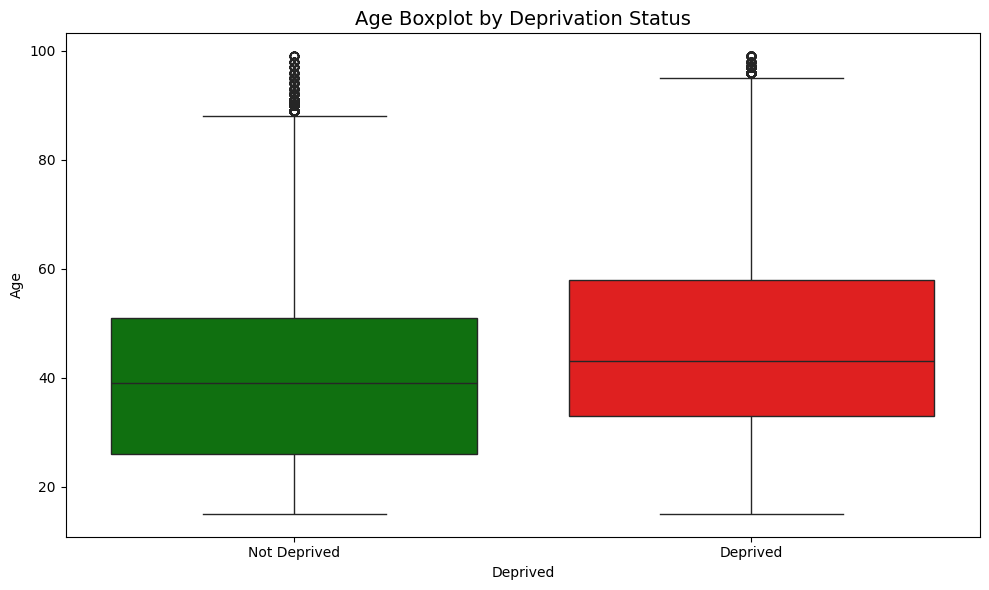

In [17]:
# ============================================
# Boxplot: سن در گروه‌های محرومیت
# ============================================

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, x='deprived', y='F2_D07', palette=['green', 'red'])
ax.set_title('Age Boxplot by Deprivation Status', fontsize=14)
ax.set_xlabel('Deprived')
ax.set_ylabel('Age')
ax.set_xticklabels(['Not Deprived', 'Deprived'])
plt.tight_layout()
plt.savefig('age_boxplot.png', dpi=300)
plt.show()

In [19]:
gender_map = {1: 'Male', 2: 'Female'}
df['Gender_Label'] = df['dep_sex'].map(gender_map)

# تحصیلات
edu_map = {
    0: 'Diploma',
    1: 'Under Diploma',

}
df['Education_Label'] = df['dep_edu'].map(edu_map)
deprived_map = {0: 'Not Deprived', 1: 'Deprived'}
df['Deprived_Label'] = df['deprived'].map(deprived_map)

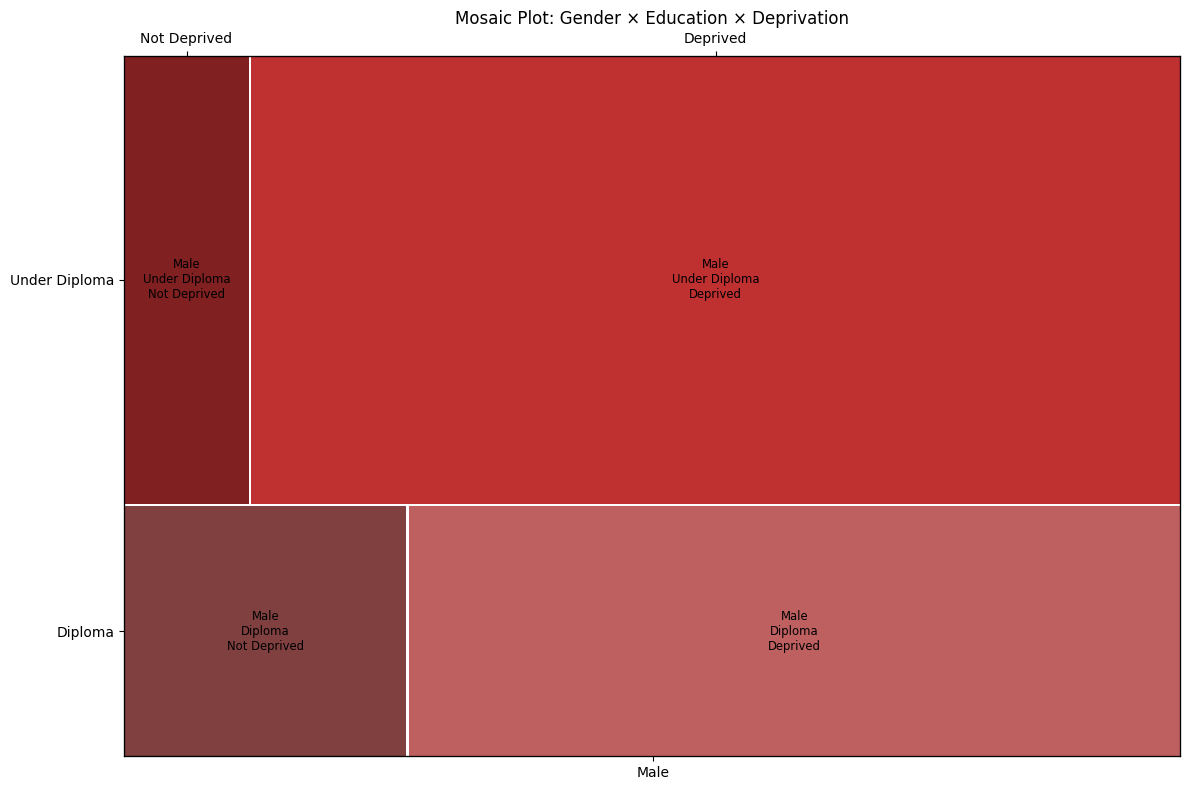

In [20]:
# ============================================
# Mosaic Plot: جنسیت × تحصیلات با محرومیت
# ============================================

from statsmodels.graphics.mosaicplot import mosaic

fig, ax = plt.subplots(figsize=(12, 8))
mosaic(df, ['Gender_Label', 'Education_Label', 'Deprived_Label'], ax=ax)
plt.title('Mosaic Plot: Gender × Education × Deprivation')
plt.tight_layout()
plt.savefig('mosaic_plot.png', dpi=300)
plt.show()

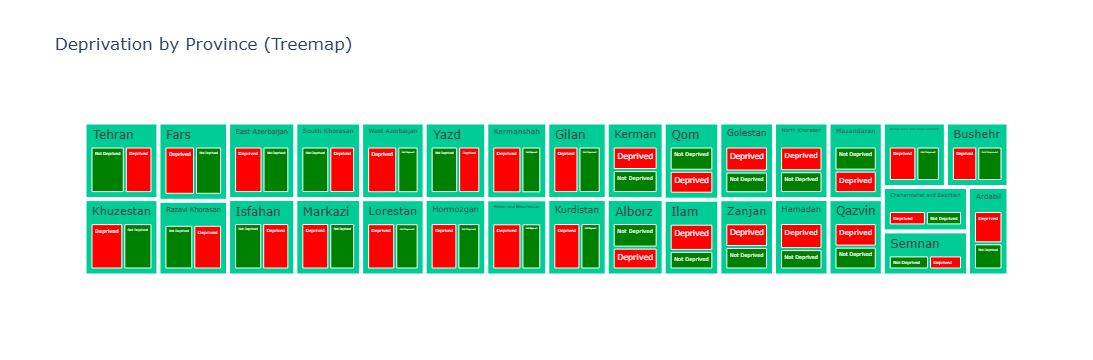

In [21]:
# ============================================
# Treemap: محرومیت در استان‌ها
# ============================================

import plotly.express as px

# محاسبه تعداد محرومان و غیرمحرومان در هر استان
province_data = df.groupby(['Province', 'deprived']).size().reset_index(name='count')
province_data['deprived_label'] = province_data['deprived'].map({0: 'Not Deprived', 1: 'Deprived'})

fig = px.treemap(
    province_data,
    path=['Province', 'deprived_label'],
    values='count',
    color='deprived_label',
    color_discrete_map={'Not Deprived': 'green', 'Deprived': 'red'},
    title='Deprivation by Province (Treemap)'
)
fig.write_html('treemap_province.html')
fig.show()

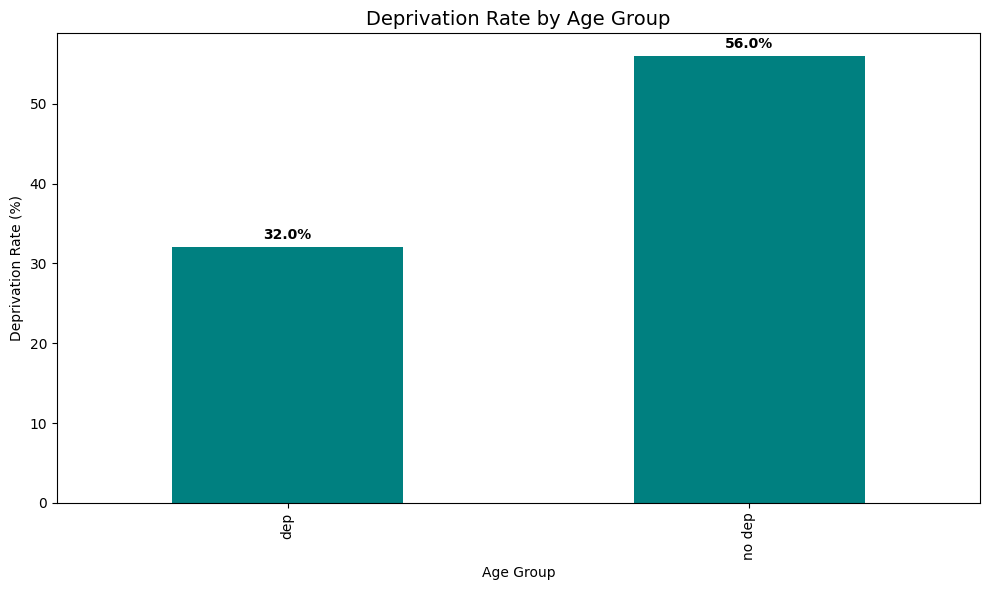

In [26]:
# ============================================
# درصد محرومیت بر اساس سن
# ============================================
age_map = {0: 'no dep', 1: 'dep'}
df['age_Label'] = df['dep_age'].map(age_map)

# گروه‌بندی سنی و محاسبه درصد محرومیت
age_dep = df.groupby('age_Label')['deprived'].mean() * 100

fig, ax = plt.subplots(figsize=(10, 6))
age_dep.plot(kind='bar', color='teal', ax=ax)
ax.set_title('Deprivation Rate by Age Group', fontsize=14)
ax.set_xlabel('Age Group')
ax.set_ylabel('Deprivation Rate (%)')
for i, v in enumerate(age_dep):
    ax.text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('deprivation_by_age1.png', dpi=300)
plt.show()

In [47]:
import plotly.graph_objects as go
import pandas as pd

# ============================================
# Sankey Diagram: جریان محرومیت
# ============================================
gender_map = {0: 'Male', 1: 'Female'}
df['Gender_Label'] = df['dep_sex'].map(gender_map)

# تحصیلات
edu_map = {
    0: 'Diploma',
    1: 'Under Diploma',

}
df['Education_Label'] = df['dep_edu'].map(edu_map)
deprived_map = {0: 'Not Deprived', 1: 'Deprived'}
df['Deprived_Label'] = df['deprived'].map(deprived_map)
region_map = {0: 'urban', 1: 'rural'}
df['region_Label'] = df['dep_urban_rural'].map(region_map)
martial_map = {0: 'single', 1: 'married'}
df['martial_Label'] = df['dep_martial_1'].map(martial_map)
age_map = {0: 'dep_age', 1: 'normal_age'}
df['age_Label'] = df['dep_age'].map(age_map)
# محاسبه جریان‌ها
gender_edu = df.groupby(['Gender_Label', 'Education_Label', 'Deprived_Label']).size().reset_index(name='count')

# گره‌ها (Nodes)
labels = ['Male', 'Female', 'Under Diploma', 'Diploma', 'Not Deprived', 'Deprived']

# اتصالات (Links)
sources = []
targets = []
values = []

# جنسیت → تحصیلات
for gender in ['Male', 'Female']:
    for edu in ['Under Diploma', 'Diploma']:
        count = df[(df['Gender_Label'] == gender) & (df['Education_Label'] == edu)].shape[0]
        if count > 0:
            sources.append(labels.index(gender))
            targets.append(labels.index(edu))
            values.append(count)

# تحصیلات → محرومیت
for edu in ['Under Diploma', 'Diploma']:
    for depr in ['Not Deprived', 'Deprived']:
        depr_val = 0 if depr == 'Not Deprived' else 1
        count = df[(df['Education_Label'] == edu) & (df['Deprived_Label'] == depr_val)].shape[0]
        if count > 0:
            sources.append(labels.index(edu))
            targets.append(labels.index(depr))
            values.append(count)

# رسم
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color='black', width=0.5),
        label=labels,
        color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#27ae60', '#e74c3c']
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values
    )
)])

fig.update_layout(title='Sankey Diagram: Gender → Education → Deprivation', font_size=12)
fig.write_html('sankey_diagram.html')
fig.show()

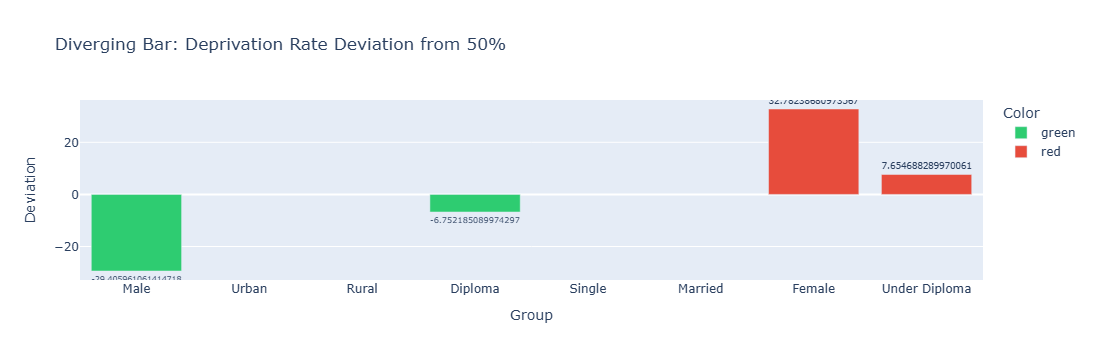

In [48]:
import plotly.express as px

# ============================================
# Diverging Bar Chart
# ============================================

# محاسبه درصد محرومیت در گروه‌های مختلف
groups = ['Male', 'Female', 'Urban', 'Rural', 'Diploma', 'Under Diploma', 'Single', 'Married']
rates = []

for group in groups:
    if group in ['Male', 'Female']:
        rate = df[df['Gender_Label'] == group]['deprived'].mean() * 100
    elif group in ['Rural', 'Urban']:
        rate = df[df['region_Label'] == group]['deprived'].mean() * 100
    elif group in ['Under Diploma', 'Diploma']:
        rate = df[df['Education_Label'] == group]['deprived'].mean() * 100
    else:
        rate = df[df['martial_Label'] == group]['deprived'].mean() * 100
    rates.append(rate - 50)  # مرکز صفر

df_diverging = pd.DataFrame({
    'Group': groups,
    'Deviation': rates,
    'Color': ['red' if r > 0 else 'green' for r in rates]
})

fig = px.bar(
    df_diverging,
    x='Group',
    y='Deviation',
    color='Color',
    color_discrete_map={'red': '#e74c3c', 'green': '#2ecc71'},
    title='Diverging Bar: Deprivation Rate Deviation from 50%',
    text='Deviation'
)

fig.update_traces(textposition='outside')
fig.write_html('diverging_bar.html')
fig.show()

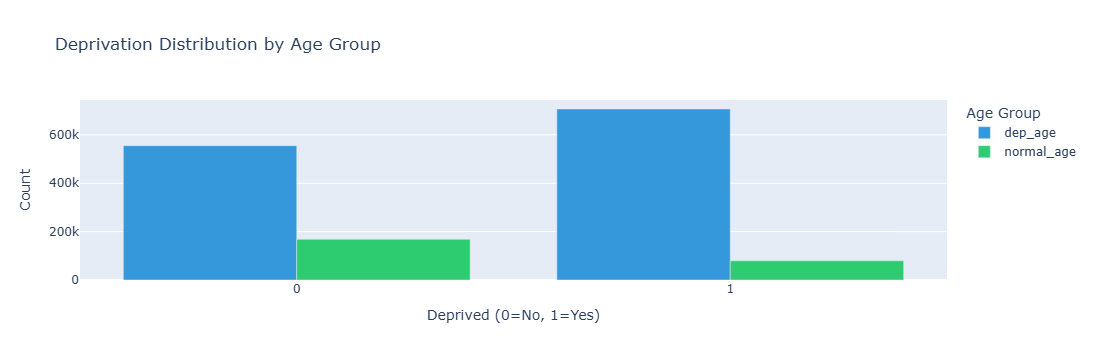

In [51]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ============================================
# Ridge Plot با Plotly
# ============================================

# برای هر گروه سنی، توزیع محرومیت
age_groups = df['age_Label'].unique()
colors = ['#3498db', '#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']

fig = go.Figure()

for i, age in enumerate(sorted(age_groups)):
    # داده‌های گروه سنی
    data = df[df['age_Label'] == age]
    
    # توزیع محرومیت
    deprived_counts = data['deprived'].value_counts().sort_index()
    
    fig.add_trace(go.Bar(
        x=deprived_counts.index,
        y=deprived_counts.values,
        name=age,
        marker_color=colors[i % len(colors)]
    ))

fig.update_layout(
    title='Deprivation Distribution by Age Group',
    xaxis_title='Deprived (0=No, 1=Yes)',
    yaxis_title='Count',
    barmode='group',
    legend_title='Age Group'
)

fig.write_html('ridge_plot.html')
fig.show()